<a href="https://colab.research.google.com/github/FaraahJ/Data-Science-Internship-Assignments/blob/Currency-Prediction-Project/AUSTRALIA_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
!pip install autots
from autots import AutoTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install calplot
import seaborn as sns

In [60]:
#loading data
data =pd.read_csv("/content/Foreign_Exchange_Rates.xls")
data.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [61]:
#dropping null values and converting timeseries to datetime
data.dropna()
data['Time Serie'] = pd.to_datetime(data['Time Serie'], format='%d-%m-%Y')

In [62]:
#Pre-processing
data.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,2000-01-04,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,2000-01-06,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,2000-01-07,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Unnamed: 0                                 5217 non-null   int64         
 1   Time Serie                                 5217 non-null   datetime64[ns]
 2   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   object        
 3   EURO AREA - EURO/US$                       5217 non-null   object        
 4   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   object        
 5   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   object        
 6   BRAZIL - REAL/US$                          5217 non-null   object        
 7   CANADA - CANADIAN DOLLAR/US$               5217 non-null   object        
 8   CHINA - YUAN/US$                           5217 non-null   object        
 9   HONG KONG - HONG KO

In [64]:
# drop unnamed columns
data.drop(columns=['Unnamed: 24', 'Unnamed: 0'])

,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,43.55,...,1.6563,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97
1,2000-01-04,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,...,1.6535,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13
2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,43.55,...,1.656,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1
3,2000-01-06,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,43.55,...,1.6655,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62
4,2000-01-07,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,43.55,...,1.6625,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5212,2019-12-25,ND,ND,ND,ND,ND,ND,ND,ND,ND,...,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
5213,2019-12-26,1.4411,0.9007,1.5002,0.7688,4.0602,1.3124,6.9949,7.788,71.28,...,1.354,6.7295,109.67,4.1337,8.8799,9.4108,181.3,0.9808,30.11,30.15
5214,2019-12-27,1.4331,0.8949,1.4919,0.7639,4.0507,1.3073,6.9954,7.7874,71.45,...,1.352,6.6829,109.47,4.126,8.8291,9.3405,181.35,0.9741,30.09,30.14
5215,2019-12-30,1.4278,0.8915,1.4846,0.761,4.0152,1.3058,6.9864,7.7857,71.3,...,1.3483,6.6589,108.85,4.1053,8.7839,9.3145,181.6,0.9677,30.04,29.94


In [65]:
#batch converting column objects to float types
rates = data.drop(columns=['Unnamed: 24', 'Unnamed: 0'])

for col in rates.columns:
    rates[col] = pd.to_numeric(rates[col], errors='coerce')

    print(rates)
print(rates.info())

               Time Serie AUSTRALIA - AUSTRALIAN DOLLAR/US$  \
0      946857600000000000                            1.5172   
1      946944000000000000                            1.5239   
2      947030400000000000                            1.5267   
3      947116800000000000                            1.5291   
4      947203200000000000                            1.5272   
...                   ...                               ...   
5212  1577232000000000000                                ND   
5213  1577318400000000000                            1.4411   
5214  1577404800000000000                            1.4331   
5215  1577664000000000000                            1.4278   
5216  1577750400000000000                            1.4225   

     EURO AREA - EURO/US$ NEW ZEALAND - NEW ZELAND DOLLAR/US$  \
0                  0.9847                              1.9033   
1                    0.97                              1.9238   
2                  0.9676                       

In [66]:
#forward/backward fill to correct NaN anomalies

rates.fillna(rates.ffill(), inplace=True)

In [67]:
#converting time feature to datetime again with newly converted data
rates['Time Serie'] = pd.to_datetime(rates['Time Serie'], format='mixed')
rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Time Serie                                 5217 non-null   datetime64[ns]
 1   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   float64       
 2   EURO AREA - EURO/US$                       5217 non-null   float64       
 3   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   float64       
 4   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   float64       
 5   BRAZIL - REAL/US$                          5217 non-null   float64       
 6   CANADA - CANADIAN DOLLAR/US$               5217 non-null   float64       
 7   CHINA - YUAN/US$                           5217 non-null   float64       
 8   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   float64       
 9   INDIA - INDIAN RUPE

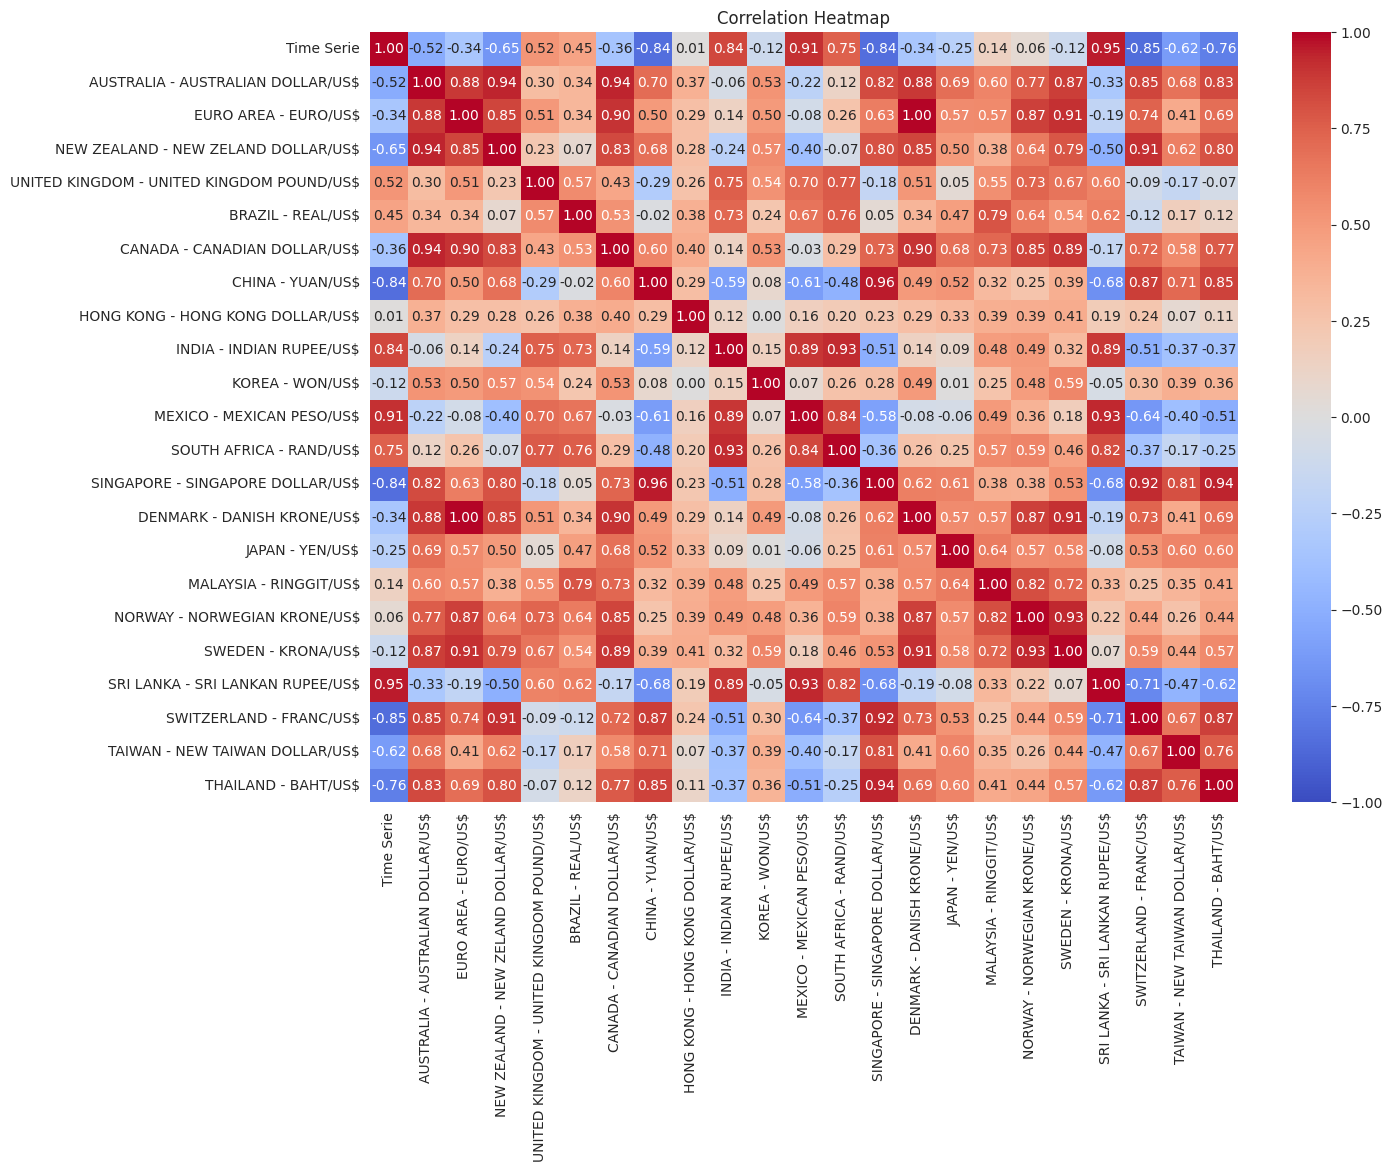

In [68]:
#EDA vizualisations:
#correlation matrix

corr_matrix = rates.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

In [69]:
rates.describe()

,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
count,5217,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,...,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000
mean,2009-12-31 09:36:19.873490688,1.332284,0.844061,1.543651,0.640725,2.550569,1.230577,7.199286,7.782593,52.759603,...,1.480183,6.287160,106.592321,3.651972,7.078344,7.901722,119.200501,1.150089,31.766274,35.519478
min,2000-01-03 00:00:00,0.906900,0.624600,1.134600,0.473800,1.537500,0.916800,6.040200,7.708500,38.480000,...,1.200700,4.660500,75.720000,2.937000,4.946700,5.834600,72.300000,0.729600,28.500000,28.600000
25%,2004-12-31 00:00:00,1.115800,0.751100,1.323600,0.587900,1.946000,1.056000,6.475800,7.756300,45.270000,...,1.342600,5.594500,100.080000,3.292000,5.998800,6.853000,100.400000,0.966800,30.350000,31.780000
50%,2009-12-31 00:00:00,1.311500,0.815800,1.442600,0.636600,2.331000,1.237200,6.859700,7.780600,48.110000,...,1.408400,6.074000,109.060000,3.800000,6.786000,7.751000,112.350000,1.038600,31.730000,34.000000
75%,2014-12-31 00:00:00,1.430600,0.900300,1.591100,0.692400,3.132000,1.335700,8.276500,7.799800,62.470000,...,1.678700,6.715300,116.820000,3.800000,8.281300,8.747400,132.800000,1.268700,32.980000,39.410000
max,2019-12-31 00:00:00,2.071300,1.209200,2.551000,0.828700,4.259400,1.612800,8.280000,7.849900,74.330000,...,1.854000,9.005000,134.770000,4.496000,9.589000,11.027000,182.800000,1.825000,35.210000,45.820000
std,NaN,0.269792,0.126685,0.337116,0.082641,0.725318,0.182147,0.819876,0.027558,9.694685,...,0.188831,0.942385,13.221191,0.379180,1.227016,1.201698,25.409982,0.248856,1.670693,4.562211


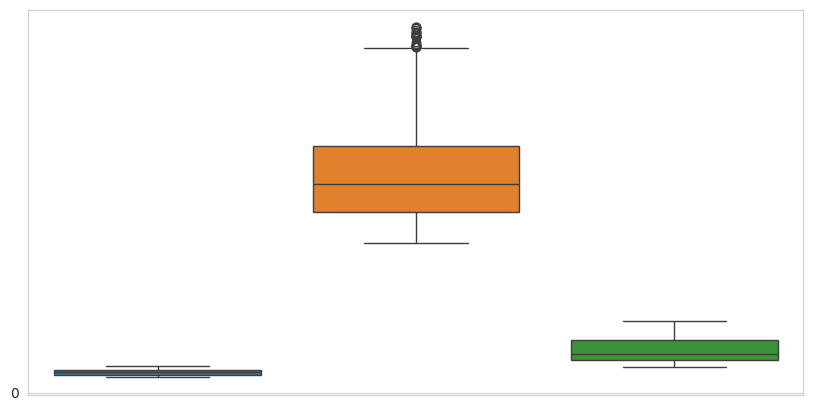

In [70]:
#box plots
## needs resizing
#individual plots
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize =(10,5))
g = sns.boxplot(data=rates[['CANADA - CANADIAN DOLLAR/US$', 'MEXICO - MEXICAN PESO/US$', 'BRAZIL - REAL/US$']])

xvalues = []
plt.xticks(np.arange(3), xvalues)

plt.yticks(np.arange(0,0.3))


plt.show()

<Figure size 1400x500 with 0 Axes>

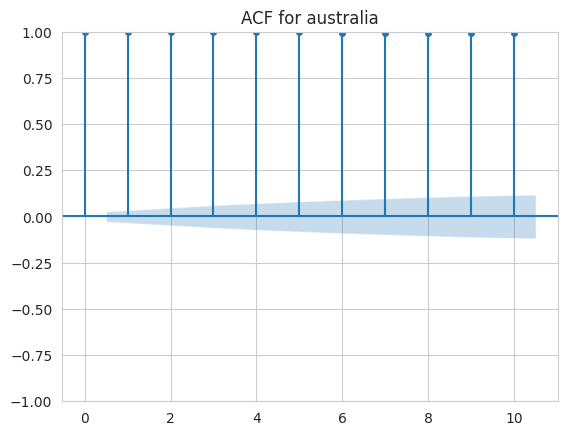

In [71]:
#Autocorrelation plot to measure similarity between data points at time intervals
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14,5))
plot_acf(rates[['AUSTRALIA - AUSTRALIAN DOLLAR/US$']], lags=10, markersize=4)
plt.title("ACF for australia")

plt.show()

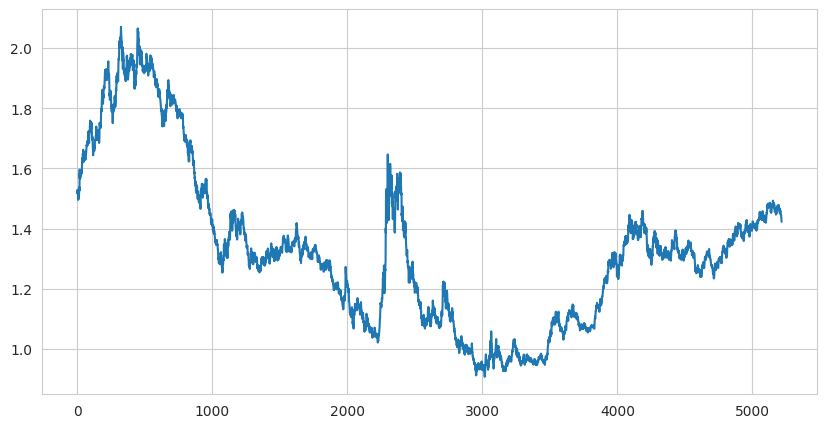

In [72]:
# ad fuller test determines if time series data is stationary
#if p-value > 0.05 significsnce level, then data isn't stationary and requires transformation
# some models dont perform well with non stationary data
from statsmodels.tsa.stattools import adfuller

plt.figure(figsize=(10,5))
plt.plot(rates['AUSTRALIA - AUSTRALIAN DOLLAR/US$'])


In [73]:
result=adfuller(rates['AUSTRALIA - AUSTRALIAN DOLLAR/US$'])
print(result)

(np.float64(-1.6539394227572606), np.float64(0.45498671724298073), 30, 5186, {'1%': np.float64(-3.4316115772743645), '5%': np.float64(-2.8620974851364487), '10%': np.float64(-2.567066749257732)}, np.float64(-32286.88630185565))


In [74]:
print('ADF Statistic', result[0]) #0 refers to corresponding statistic in first position in the list above
print('p-value', result[1])
print('Number of Lags', result[2])#lags are previous timestamps compared to current timestamps
print('Observations used in test', result[3])
print('Critical Values', result[4])
print('IC', result[5]) #information criteria - negative means various variables used in testing, stable data


ADF Statistic -1.6539394227572606
p-value 0.45498671724298073
Number of Lags 30
Observations used in test 5186
Critical Values {'1%': np.float64(-3.4316115772743645), '5%': np.float64(-2.8620974851364487), '10%': np.float64(-2.567066749257732)}
IC -32286.88630185565


In [75]:
#associating objects to statistics
adf_stat, p_value, lags, n_obs, crit_values, ic_best = result
print(p_value)

0.45498671724298073


In [76]:
def adf_test(series):
  result = adfuller(series)
  print(f'p_value: {result[1]}')

if result[1] <= 0.05:
  print("reject null hypothesis, data is stationary")
else:
  print:("data is not stationary")

In [77]:
adf_test(rates['AUSTRALIA - AUSTRALIAN DOLLAR/US$'])
#data is not stationary

p_value: 0.45498671724298073


In [78]:
#selecting currency

options = {
    'AUSTRALIAN DOLLAR': 'AUSTRALIA - AUSTRALIAN DOLLAR/US$',
    'EURO': 'EURO AREA - EURO/US$',
    'NEW ZEALAND DOLLAR': 'NEW ZEALAND - NEW ZEALAND DOLLAR/US$',
    'GREAT BRITAIN POUNDS': 'UNITED KINGDOM - UNITED KINGDOM POUND/US$',
    'BRAZILIAN REAL': 'BRAZIL - REAL/US$',
    'CANADIAN DOLLAR': 'CANADA - CANADIAN DOLLAR/US$',
    'CHINESE YUAN$': 'CHINA - YUAN/US$',
    'HONG KONG DOLLAR': 'HONG KONG - HONG KONG DOLLAR/US$',
    'INDIAN RUPEE': 'INDIA - INDIAN RUPEE/US$',
    'KOREAN WON$': 'KOREA - WON/US$',
    'MEXICAN PESO': 'MEXICO - MEXICAN PESO/US$',
    'SOUTH AFRICAN RAND$': 'SOUTH AFRICA - RAND/US$',
    'SINGAPORE DOLLAR': 'SINGAPORE - SINGAPORE DOLLAR/US$',
    'DANISH KRONE': 'DENMARK - DANISH KRONE/US$',
    'JAPANESE YEN$': 'JAPAN - YEN/US$',
    'MALAYSIAN RINGGIT': 'MALAYSIA - RINGGIT/US$',
    'NORWEGIAN KRONE': 'NORWAY - NORWEGIAN KRONE/US$',
    'SWEDEN KRONA': 'SWEDEN - KRONA/US$',
    'SRILANKAN RUPEE': 'SRI LANKA - SRI LANKAN RUPEE/US$',
    'SWISS FRANC': 'SWITZERLAND - FRANC/US$',
    'NEW TAIWAN DOLLAR': 'TAIWAN - NEW TAIWAN DOLLAR/US$',
    'THAI BAHT': 'THAILAND - BAHT/US$'
}

selected_option = 'AUSTRALIAN DOLLAR'

In [79]:
#ARIMA/SARIMA Model

import plotly.express as px
from scipy.stats import boxcox

column_to_transform = 'AUSTRALIA - AUSTRALIAN DOLLAR/US$'

# Ensure data is positive for boxcox transformation
# This shift helps if previous normalization introduced negative values.
# For ARIMA/SARIMA, boxcox is typically applied to raw positive data before differencing.
if rates[column_to_transform].min() <= 0:
    rates[column_to_transform] = rates[column_to_transform] - rates[column_to_transform].min() + 1e-6

# Apply Box-Cox transformation and store in a new column
rates['AUSTRALIA_boxcox'], lam = boxcox(rates[column_to_transform])

# Calculate the differenced series from the box-cox transformed data
rates["AUSTRALIA_diff"] = rates["AUSTRALIA_boxcox"].diff()
rates.dropna(inplace=True)

# Plot the differenced series using plotly.express
fig = px.line(rates, x='Time Serie', y='AUSTRALIA_diff', title='Differenced Box-Cox Transformed Australian Dollar Rates')
fig.show()

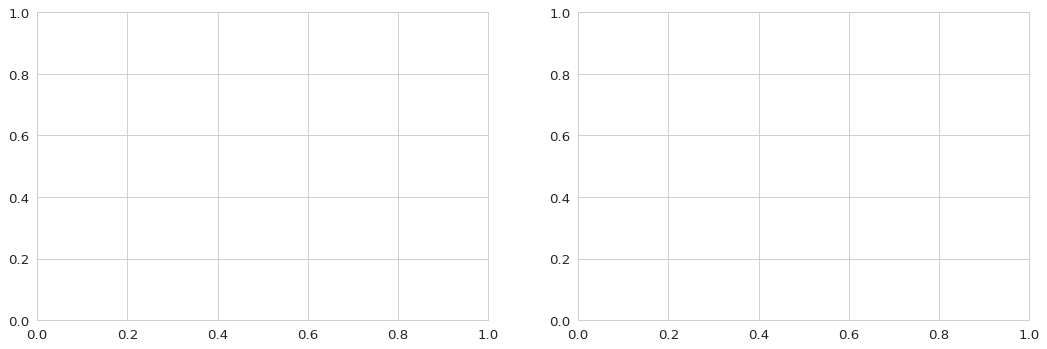

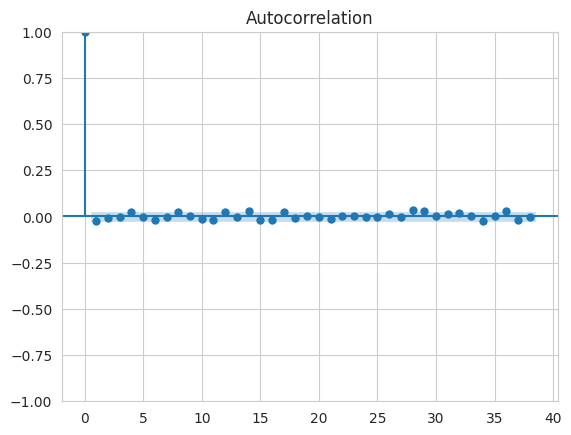

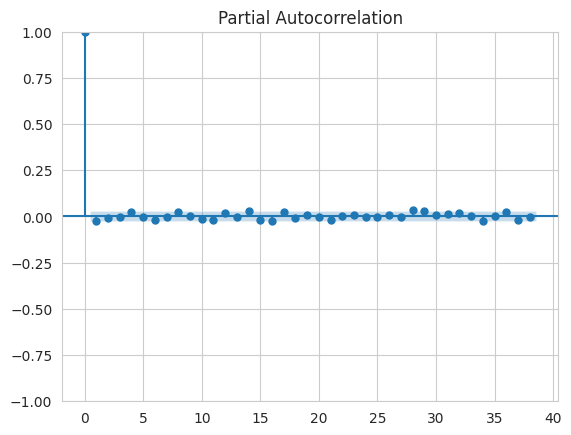

In [80]:
#Autocorrelation plot to measure similarity between data points at time intervals
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=80)
plot_acf(rates['AUSTRALIA_diff'])
plot_pacf(rates['AUSTRALIA_diff'], method='ywm')
ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)
plt.show()


In [81]:
#SARIMA order (p,d,q)(P,D,Q)12 for monthly seasons
# Australia - (0,1,0)(0,1,0)12
#fitting ARIMA model

from scipy.special import inv_boxcox
from statsmodels.tsa.arima.model import ARIMA

#train/test
train = rates.iloc[:-int(len(rates) * 0.2)]
test = rates.iloc[-int(len(rates) * 0.2):]

#ARIMA building
model= ARIMA(train['AUSTRALIA_boxcox'], order=(0, 1, 0),
             seasonal_order=(0, 1, 0, 12)).fit()
boxcox_forecasts = model.forecast(len(test))
forecasts = inv_boxcox(boxcox_forecasts, lam)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: Value

In [82]:
#plotting SARIMA forecasts
import plotly.graph_objects as go

def plot_forecasts(forecasts: list[float], title: str) -> None:

    fig  = go.Figure()
    fig.add_trace(go.Scatter(x=train['Time Serie'], y=train['AUSTRALIA - AUSTRALIAN DOLLAR/US$'], name='Train'))
    fig.add_trace(go.Scatter(x=test['Time Serie'], y=test['AUSTRALIA - AUSTRALIAN DOLLAR/US$'], name='Test'))
    fig.add_trace(go.Scatter(x=test['Time Serie'], y=forecasts, name='Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Date',
                      yaxis_title='Australian Dollar Exchnage Rates')

    return fig.show()

plot_forecasts(forecasts, 'SARIMA')

In [83]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np

# Assuming forecasts align with the test set's time frame
# Handle potential NaN values in forecasts and align with actual test data

# First, ensure the forecasts have the correct time index corresponding to the test set
# Since forecasts and test have the same length (1043), we can simply assign the test index.
forecasts_aligned = forecasts.copy()
forecasts_aligned.index = test.index

# Align forecasts and test_data by dropping NaNs from forecasts and taking corresponding test values
predictions_cleaned = forecasts_aligned.dropna()
# Ensure the test data is sliced to match the length of the cleaned predictions
# We take the actual values from the 'AUSTRALIA - AUSTRALIAN DOLLAR/US$' column of the test set
test_data_cleaned = test['AUSTRALIA - AUSTRALIAN DOLLAR/US$'].loc[predictions_cleaned.index]

# Calculate metrics
mae = mean_absolute_error(test_data_cleaned, predictions_cleaned)
mape = mean_absolute_percentage_error(test_data_cleaned, predictions_cleaned)
rmse = np.sqrt(mean_squared_error(test_data_cleaned, predictions_cleaned))

print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape * 100:.2f}%")
print(f"RMSE: {rmse:.4f}")

MAE: 0.5099
MAPE: 37.11%
RMSE: 0.5750


/tmp/ipykernel_17260/1521585289.py:3: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='AUSTRALIA - AUSTRALIAN DOLLAR/US$', ylabel='Density'>

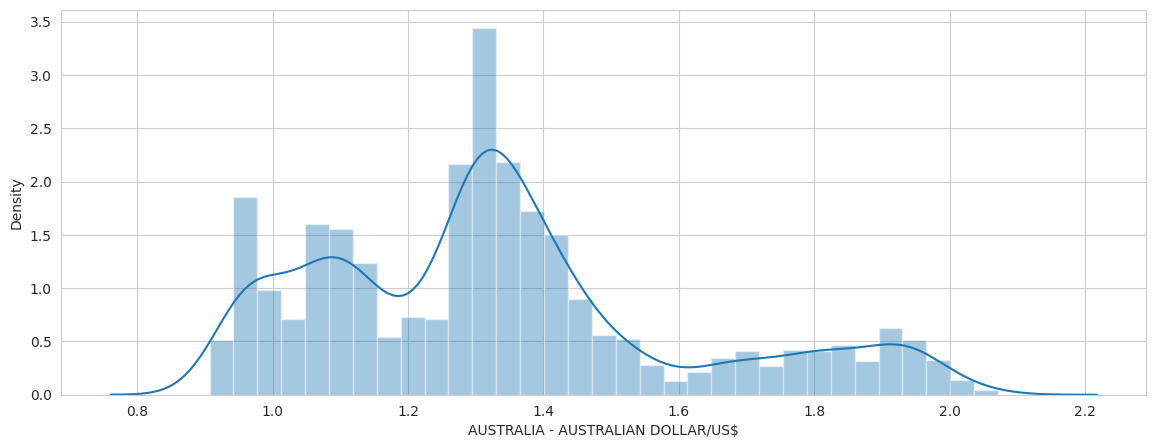

In [84]:
# checking if selected data is normally distributed
plt.figure(figsize = (14,5))
sns.distplot(rates['AUSTRALIA - AUSTRALIAN DOLLAR/US$'])

In [85]:
# data normalisation (if required)
rates['AUSTRALIA - AUSTRALIAN DOLLAR/US$'] = (rates['AUSTRALIA - AUSTRALIAN DOLLAR/US$'] - rates['AUSTRALIA - AUSTRALIAN DOLLAR/US$'].mean())/rates['AUSTRALIA - AUSTRALIAN DOLLAR/US$'].std()

In [86]:
#LSTM MODEL - train test split

def Sequential_Input_LSTM(rates, input_sequence):
    rates_np = rates.to_numpy()
    X = []
    y = []

    for i in range(len(rates_np) - input_sequence):
        row = [a for a in rates_np[i:i + input_sequence]]
        X.append(row)
        label = rates_np[i + input_sequence]
        y.append(label)

    return np.array(X), np.array(y)

In [87]:
n_input = 10      # number of historical inputs to be used for forecasting the future time series

rates_min_model_data = rates['AUSTRALIA - AUSTRALIAN DOLLAR/US$']

X, y = Sequential_Input_LSTM(rates_min_model_data, n_input)

In [88]:
X.shape, y.shape

((5206, 10), (5206,))

In [89]:
# Training data
X_train, y_train = X[:1400], y[:1400]

# Validation data
X_val, y_val = X[1400:1600], y[1400:1600]

# Test data
X_test, y_test = X[1600:], y[1600:]

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [91]:
X_train.shape, y_train.shape


((4164, 10), (4164,))

In [92]:
X_val.shape, y_val.shape

((200, 10), (200,))

In [93]:
X_test.shape, y_test.shape

((1042, 10), (1042,))

In [94]:
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam

In [95]:
n_features = 1                        # number of input variables used for forecast (here, only 1 i.e. temperature)

model1 = Sequential()

model1.add(InputLayer((n_input,n_features)))
model1.add(LSTM(100, return_sequences = True))
model1.add(LSTM(100, return_sequences = True))
model1.add(LSTM(50))
model1.add(Dense(8, activation = 'relu'))
model1.add(Dense(1, activation = 'linear'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,817 (593.04 KB)

 Trainable params: 151,817 (593.04 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
early_stop = EarlyStopping(monitor = 'val_loss', patience = 2)

model1.compile(loss = MeanSquaredError(), optimizer = Adam(learning_rate = 0.0001), metrics = [RootMeanSquaredError()])

In [97]:
model1.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = 50, callbacks = [early_stop])

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.3473 - root_mean_squared_error: 0.5893 - val_loss: 0.0086 - val_root_mean_squared_error: 0.0926
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0124 - root_mean_squared_error: 0.1113 - val_loss: 0.0060 - val_root_mean_squared_error: 0.0774
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0093 - root_mean_squared_error: 0.0966 - val_loss: 0.0055 - val_root_mean_squared_error: 0.0740
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0089 - root_mean_squared_error: 0.0942 - val_loss: 0.0051 - val_root_mean_squared_error: 0.0716
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0087 - root_mean_squared_error: 0.0935 - val_loss: 0.0049 - val_root_mean_squared_error: 0.0698
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0086 - root_mean_squared_error: 0.0929 - val_loss: 0.0048 - val_root_mean_squared_error: 0.0691
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 33m

In [98]:
losses_df1 = pd.DataFrame(model1.history.history)
losses_df1

,loss,root_mean_squared_error,val_loss,val_root_mean_squared_error
0,0.347293,0.589316,0.008578,0.092617
1,0.012377,0.111253,0.005990,0.077395
2,0.009339,0.096636,0.005478,0.074013
3,0.008878,0.094223,0.005131,0.071632
4,0.008738,0.093476,0.004871,0.069793
5,0.008628,0.092888,0.004770,0.069066
6,0.008414,0.091728,0.004802,0.069296
7,0.008359,0.091429,0.004681,0.068419
8,0.008307,0.091141,0.004729,0.068770
9,0.008343,0.091340,0.004617,0.067951


In [99]:
scores = model1.evaluate(X_test, y_test, verbose=0)
print("%s: %.2f%%" % (model1.metrics_names[0], scores[0]*100))
print("%s: %.2f%%" % ('RootMeanSquaredError', scores[1]*100))

loss: 0.77%
RootMeanSquaredError: 8.79%


<Axes: >

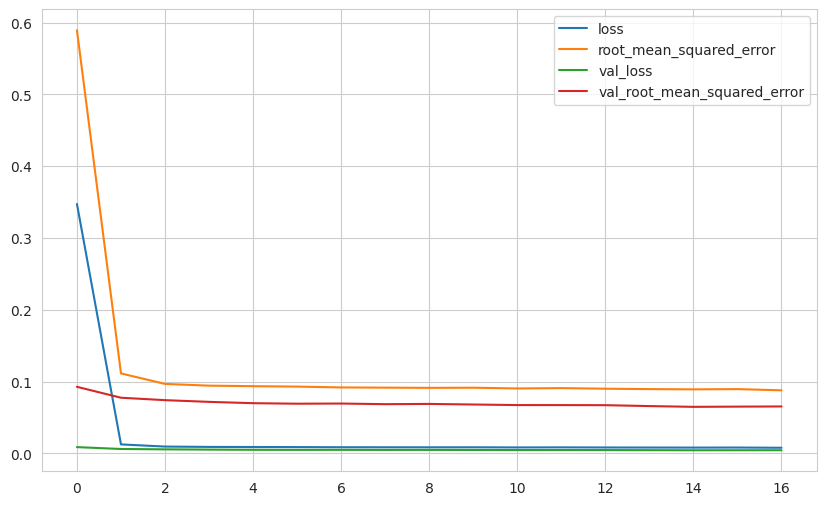

In [100]:
losses_df1.plot(figsize = (10,6))

In [101]:
test_predictions1 = model1.predict(X_test).flatten()
test_predictions1

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


array([ 2.3245108 ,  2.1221473 , -0.30836797, ...,  0.1875578 ,
        0.66058403,  0.26053548], dtype=float32)

In [102]:
len(X_test), len(test_predictions1)

(1042, 1042)

In [103]:
test_predictions1.ndim #1 for time series forecast

1

In [104]:
X_test_list = []
for i in range(len(X_test)):
    X_test_list.append(X_test[i][0])

len(X_test_list)

1042

In [105]:
test_predictions_df1 = pd.DataFrame({'X_test':list(X_test_list), 'LSTM Prediction':list(test_predictions1)})
len(test_predictions_df1)

1042

In [106]:
test_predictions_df1.head()

,X_test,LSTM Prediction
0,2.358178,2.324511
1,2.143580,2.122147
2,-0.318558,-0.308368
3,0.154745,0.181930
4,0.096555,0.072937


In [107]:
y_predicted = test_predictions_df1['LSTM Prediction']

mae_metric = MeanAbsoluteError()
mae_metric.update_state(y_test, y_predicted)
mae_result = mae_metric.result().numpy()

print(f"Test MAE: {mae_result}")

Test MAE: 0.06365080922842026


In [108]:
def calculate_mape(actual, predicted):
    absolute_errors = np.abs(actual - predicted)
    percentage_errors = absolute_errors / actual
    mape = np.mean(percentage_errors) * 100
    return mape

mape = calculate_mape(y_predicted, y_test)
print("MAPE:", mape, "%")

MAPE: -18.253410793058666 %


In [109]:
#Prophet MODEL
!pip install Prophet

In [110]:
from prophet import Prophet

In [111]:
#rennaming date and chosen currency columns into ds/y format for prophet model

df_prophet = rates[["Time Serie", "AUSTRALIA - AUSTRALIAN DOLLAR/US$"]].rename(columns = {"Time Serie": "ds", "AUSTRALIA - AUSTRALIAN DOLLAR/US$":"y"})

df_prophet.tail()

,ds,y
5212,2019-12-25,0.416043
5213,2019-12-26,0.403442
5214,2019-12-27,0.373791
5215,2019-12-30,0.354147
5216,2019-12-31,0.334503


In [112]:
model = Prophet()
model.fit(df_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [113]:
future_dates = pd.date_range(start = "2020-01-01", periods = 30, freq = "D")

In [114]:
df_future = pd.DataFrame({"ds": future_dates})

In [115]:
df_future.head()

,ds
0,2020-01-01
1,2020-01-02
2,2020-01-03
3,2020-01-04
4,2020-01-05


In [116]:
#making forecasts

forecast = model.predict(df_future)

In [117]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
0,2020-01-01,0.283473,0.016941,0.532431
1,2020-01-02,0.278016,0.034992,0.518130
2,2020-01-03,0.274601,0.022934,0.532665
3,2020-01-04,0.094720,-0.154236,0.340150
4,2020-01-05,0.090428,-0.165990,0.333940


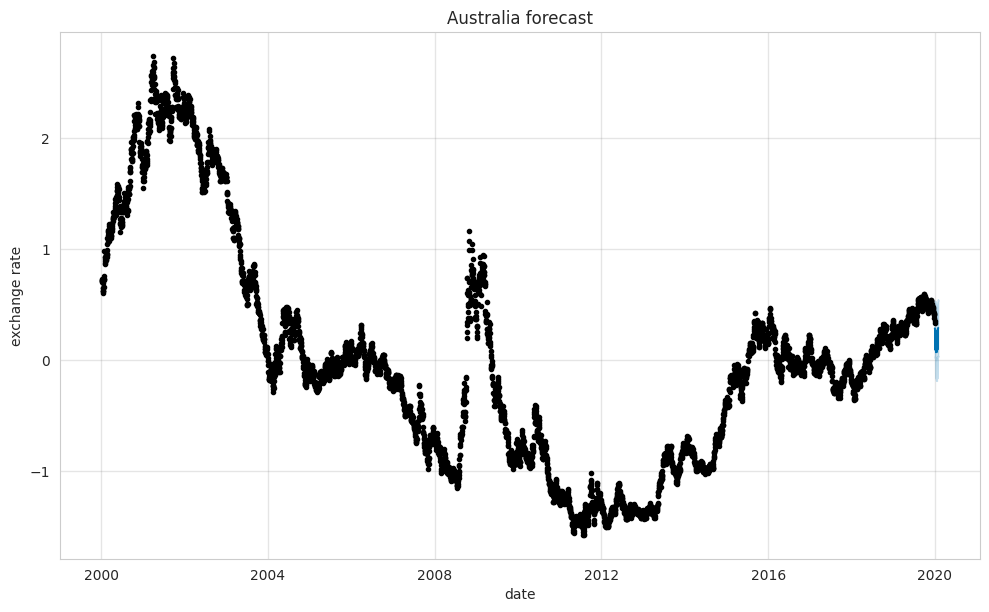

In [118]:
model.plot(forecast)
plt.title("Australia forecast")
plt.xlabel("date")
plt.ylabel("exchange rate")
plt.show()

In [119]:
#prophet evaluation metrics
from prophet.diagnostics import cross_validation, performance_metrics
df_cv = cross_validation(model, initial='365 days', period='180 days', horizon='30 days')

INFO:prophet:Making 39 forecasts with cutoffs between 2001-03-10 00:00:00 and 2019-12-01 00:00:00


  0%|          | 0/39 [00:00<?, ?it/s]

In [120]:
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'mae', 'rmse', 'mape']])

   horizon       mae      rmse      mape
0   3 days  0.250209  0.324765  5.756188
1   4 days  0.250631  0.320962  5.592002
2   5 days  0.255396  0.315320  5.427173
3   6 days  0.259527  0.319126  1.168371
4   7 days  0.270633  0.338948  1.302815
5   8 days  0.272820  0.351926  1.353437
6   9 days  0.264046  0.343991  1.374958
7  10 days  0.267364  0.347567  1.394110
8  11 days  0.261935  0.335627  1.634422
9  12 days  0.263163  0.326449  1.882973
10 13 days  0.262664  0.317240  1.940915
11 14 days  0.278166  0.333974  1.754396
12 15 days  0.290266  0.354792  2.076210
13 16 days  0.289075  0.366415  2.052130
14 17 days  0.284836  0.370283  3.018221
15 18 days  0.270738  0.351095  2.719580
16 19 days  0.271659  0.339174  2.657154
17 20 days  0.280264  0.343000  1.457813
18 21 days  0.295129  0.365815  1.250883
19 22 days  0.297518  0.382576  1.346402
20 23 days  0.290634  0.383575  1.383495
21 24 days  0.291268  0.388032  1.429670
22 25 days  0.289126  0.374676  1.293711
23 26 days  0.29